# **📏📐 Feature Scaling**

- Scikit-learn Preprocessing
- https://scikit-learn.org/stable/api/sklearn.preprocessing.html
- Methods for scaling, centering, normalization, binarization, and more.

| Scaler              | Handles Outliers? | Preserves Sparsity? | Output Range      | Suitable for   |
| ------------------- | ----------------- | ------------------- | ----------------- | -------------- |
| StandardScaler      | ❌                 | ❌                   | Centered around 0 | Most ML models |
| MinMaxScaler        | ❌                 | ❌                   | \[0, 1]           | NN, SVM        |
| RobustScaler        | ✅                 | ❌                   | Varies            | Outliers       |
| MaxAbsScaler        | ❌                 | ✅                   | \[-1, 1]          | Sparse data    |
| Normalizer          | ❌                 | ✅                   | Unit norm per row | k-NN, Cosine   |
| QuantileTransformer | ✅                 | ❌                   | Uniform or Normal | Skewed data    |
| PowerTransformer    | ✅                 | ❌                   | Gaussian-like     | Linear models  |


In [1]:
import pandas as pd
import numpy as np

In [2]:
# Sample dataset
X = pd.DataFrame({
    'income': [50000, 64000, 58000, 120000, 45000],
    'age': [25, 45, 35, 52, 23],
    'transactions': [1, 4, 2, 10, 3]
})

---
# StandardScaler (Z-score normalization)

Use when: Data is normally distributed or you plan to use models that assume Gaussian-like input (e.g. logistic regression, SVM, KNN).

Effect: Mean = 0, Std = 1.

In [3]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_standard = scaler.fit_transform(X)
print("StandardScaler:\n", pd.DataFrame(X_standard, columns=X.columns))

StandardScaler:
      income       age  transactions
0 -0.642141 -0.981517     -0.948683
1 -0.125476  0.803059      0.000000
2 -0.346904 -0.089229     -0.632456
3  1.941184  1.427661      1.897367
4 -0.826664 -1.159975     -0.316228


# MinMaxScaler (Normalization to [0, 1])

- Use when: You need data between a specific range, e.g. in neural networks.

- Effect: Scales data to [0, 1].

In [4]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_minmax = scaler.fit_transform(X)
print("MinMaxScaler:\n", pd.DataFrame(X_minmax, columns=X.columns))

MinMaxScaler:
      income       age  transactions
0  0.066667  0.068966      0.000000
1  0.253333  0.758621      0.333333
2  0.173333  0.413793      0.111111
3  1.000000  1.000000      1.000000
4  0.000000  0.000000      0.222222


# RobustScaler (Robust to outliers)

- Use when: Data has many outliers.

- Effect: Centers using median and scales using IQR (interquartile range).

In [5]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_robust = scaler.fit_transform(X)
print("RobustScaler:\n", pd.DataFrame(X_robust, columns=X.columns))

RobustScaler:
      income   age  transactions
0 -0.571429 -0.50          -1.0
1  0.428571  0.50           0.5
2  0.000000  0.00          -0.5
3  4.428571  0.85           3.5
4 -0.928571 -0.60           0.0


# MaxAbsScaler (Preserves sparsity)

- Use when: Your data is sparse (many zeros) or you want to preserve sign and scale between -1 and 1.

- Effect: Divides by maximum absolute value per feature.

In [6]:
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()
X_maxabs = scaler.fit_transform(X)
print("MaxAbsScaler:\n", pd.DataFrame(X_maxabs, columns=X.columns))

MaxAbsScaler:
      income       age  transactions
0  0.416667  0.480769           0.1
1  0.533333  0.865385           0.4
2  0.483333  0.673077           0.2
3  1.000000  1.000000           1.0
4  0.375000  0.442308           0.3


# Normalizer (Normalize each row — not column)

- Use when: You care about direction but not magnitude, such as in text classification (TF-IDF) or k-NN.

- Effect: Row-wise vector normalization to unit norm.

In [7]:
from sklearn.preprocessing import Normalizer
scaler = Normalizer(norm='l2')  # or 'l1'
X_normalized = scaler.fit_transform(X)
print("Normalizer:\n", pd.DataFrame(X_normalized, columns=X.columns))

Normalizer:
    income       age  transactions
0     1.0  0.000500      0.000020
1     1.0  0.000703      0.000062
2     1.0  0.000603      0.000034
3     1.0  0.000433      0.000083
4     1.0  0.000511      0.000067


# QuantileTransformer (Uniform or Gaussian output)

- Use when: Data is highly skewed or non-Gaussian.

- Effect: Non-linear transformation — maps data to uniform or normal distribution.

In [8]:
from sklearn.preprocessing import QuantileTransformer
scaler = QuantileTransformer(output_distribution='normal')  # or 'uniform'
X_quantile = scaler.fit_transform(X)
print("QuantileTransformer (normal):\n", pd.DataFrame(X_quantile, columns=X.columns))

QuantileTransformer (normal):
      income       age  transactions
0 -0.674490 -0.674490     -5.199338
1  0.674490  0.674490      0.674490
2  0.000000  0.000000     -0.674490
3  5.199338  5.199338      5.199338
4 -5.199338 -5.199338      0.000000


c:\Users\joeln\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (5). n_quantiles is set to n_samples.
  warnings.warn(


# PowerTransformer (Box-Cox or Yeo-Johnson)

- Use when: You want to make data more Gaussian-like, especially for linear models.

- Effect: Stabilizes variance and reduces skewness.

In [9]:
from sklearn.preprocessing import PowerTransformer
scaler = PowerTransformer(method='yeo-johnson')  # use 'box-cox' for strictly positive data
X_power = scaler.fit_transform(X)
print("PowerTransformer:\n", pd.DataFrame(X_power, columns=X.columns))

PowerTransformer:
      income       age  transactions
0 -0.687326 -0.988445     -1.469125
1  0.394479  0.856713      0.427606
2  0.025823  0.063717     -0.533529
3  1.605864  1.315148      1.540447
4 -1.338843 -1.247134      0.034601


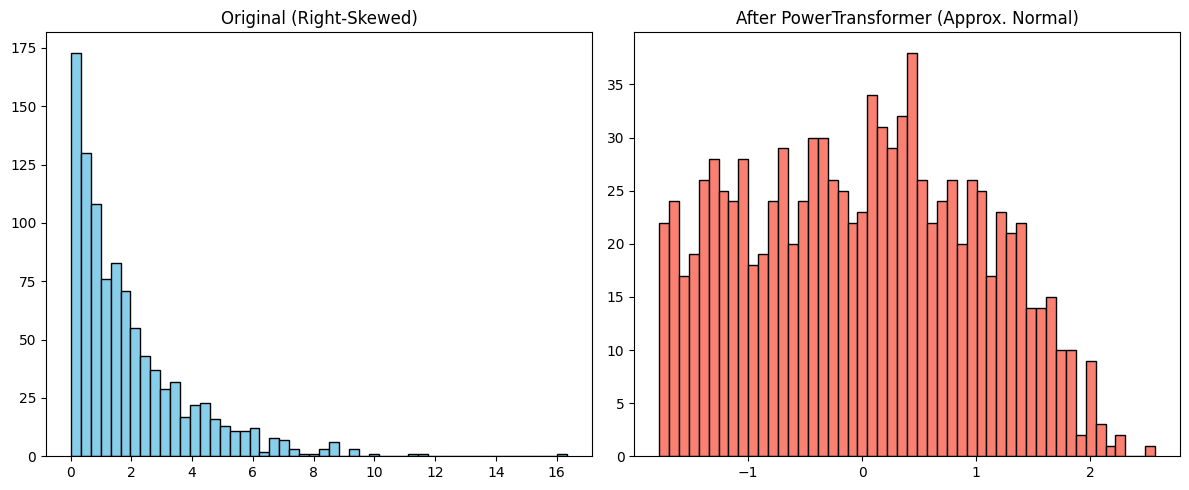

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

# Generate a right-skewed distribution
np.random.seed(42)
data = np.random.exponential(scale=2, size=(1000, 1))

# Apply PowerTransformer (Yeo-Johnson by default)
pt = PowerTransformer(method='yeo-johnson')
data_transformed = pt.fit_transform(data)

# Plot before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before
axes[0].hist(data, bins=50, color='skyblue', edgecolor='k')
axes[0].set_title("Original (Right-Skewed)")

# After
axes[1].hist(data_transformed, bins=50, color='salmon', edgecolor='k')
axes[1].set_title("After PowerTransformer (Approx. Normal)")

plt.tight_layout()
plt.show()